#**Programming Principles for AI**
## Lecture 3: Reusing code, making it robust, and working with data
In this lesson we will learn how to create our own functions and classes, and how to analyze data


---

## **Functions in Python**: Organizing and reusing logic

Until now, every time we need to perform an operation, we write the corresponding instructions directly in our program.

For example:

In [ ]:
price = 120
discount = 0.20

final_price = price * (1 - discount)

print(final_price)

This works.

But what if we need to calculate discounted prices many times?

In [ ]:
price_1 = 120
discount_1 = 0.20
final_price_1 = price_1 * (1 - discount_1)

price_2 = 80
discount_2 = 0.10
final_price_2 = price_2 * (1 - discount_2)

price_3 = 350
discount_3 = 0.15
final_price_3 = price_3 * (1 - discount_3)

print(final_price_1)
print(final_price_2)
print(final_price_3)

We are repeating the **same logic** several times.

A **function** allows us to give a name to a sequence of instructions and reuse it whenever we need it.

We have already been **calling** functions since Lesson 1:

```python
print(...)
len(...)
sum(...)
round(...)

### **Defining a function**

Functions are defined using the `def` keyword.

In [16]:
def say_hello():
    print("Hello!")

What happens when we execute the previous cell?

Nothing is printed.

The code inside the function is **defined**, but it is not executed yet.

To execute the function, we need to **call** it.

In [17]:
say_hello()

Hello!


A function definition has the following basic structure:

```python
def function_name():
    # Instructions executed by the function

### **Exercise**

Define a function called `welcome()` that prints:

```text
Welcome to Programming Principles for AI!

In [18]:
def welcome():
  print('welcome to ...')

In [19]:
welcome()

welcome to ...


---

### **Making functions work with different data**

Our `say_hello()` function always does exactly the same thing.

What if we want to greet different people?

In [20]:
def greet(name):
    print("Hello", name)

In [21]:
greet(name="Anna")
greet("Mario")
greet("John")

Hello Anna
Hello Mario
Hello John


The variable `name` in the function definition is called a **parameter**.

When we call the function:

```python
greet("Anna")
```

the value "Anna" is passed to the parameter name.
The value provided when calling the function is called an argument.

### **Exercise**

Define a function called `calculate_area(width, height)` that calculates and prints the area of a rectangle.

Test it with:

```python
calculate_area(5, 3)
calculate_area(10, 7)

In [22]:
def calculate_area(width, height):
  print(width*height)

In [23]:
calculate_area(5, 3)

15


---

### **Returning values from functions**

So far, our functions have printed their results.

But printing a result and **returning** a result are not the same thing.

In [24]:
def calculate_total(price, quantity):
    print(price * quantity)

In [25]:
result = calculate_total(20, 3)

print("Result:", result)

60
Result: None


What happened?

The function printed `60`, but the variable `result` contains `None`.

Why?

`print()` only displays information on the screen.

It does **not** send that value back to the part of the program that called the function.

If we want a function to produce a value that can be used later, we use `return`.

In [26]:
def calculate_total(price, quantity):
    return price * quantity

In [27]:
result = calculate_total(20, 3)

print("Result:", result)

Result: 60


Now the function **returns** the calculated value.

This means that we can store it:

In [28]:
total = calculate_total(50, 4)

print(total)

200


Or use it directly in another expression:

In [ ]:
total_with_tax = calculate_total(50, 4) * 1.22

print(total_with_tax)

A useful way to think about functions is:

> **Inputs → Function → Output**

### **Exercise: Discounted price**

Define a function called:

```python
calculate_discounted_price(price, discount)

In [31]:
def calculate_discounted_price(price, disc):
    return price * (1 - disc)

In [32]:
calculate_discounted_price(100, 0.20)

80.0

---

### **Functions can contain the logic we already know**

A function can contain variables, expressions, conditions, loops, and other function calls.

For example, we can move our previous product classification logic into a function.

In [35]:
def classify_price(price):
    if price > 500:
        return "Premium"
    elif price > 100:
        return "Standard"
    else:
        return "Budget"

In [36]:
print(classify_price(800))
print(classify_price(350))
print(classify_price(50))

Premium
Standard
Budget


Notice that the function can return **different values depending on the execution path**.

For example:

```python
classify_price(800)
```

Once return is executed, the function ends and sends the result back to the caller.

### **Exercise: Product availability**

Define a function called:

```python
stock_status(stock)
```

The function should:

- return "Out of stock" if stock == 0
- return "Low stock" if stock < 5
- return "Available" otherwise

In [41]:
def stock_status(stock):
  if stock == 0:
    return "out of stock"
  elif stock < 5:
    return "low stock"
  else:
    return "available"

In [43]:
stock_status(10)

'available'

---

### **Functions can also contain loops**

Earlier, we calculated the factorial of a number using a loop.

We can now package that algorithm inside a function.

In [ ]:
def factorial(n):
    result = 1

    for number in range(1, n + 1):
        result = result * number

    return result

In [ ]:
print(factorial(5))
print(factorial(7))

Let's combine:

- collections
- loops
- conditions
- functions
- return values

In [ ]:
products = [
    {"name": "Laptop", "price": 1200, "stock": 5},
    {"name": "Mouse", "price": 25, "stock": 0},
    {"name": "Monitor", "price": 350, "stock": 12},
    {"name": "Keyboard", "price": 80, "stock": 7}
]

In [ ]:
def count_available(products):
    count = 0

    for product in products:
        if product["stock"] > 0:
            count = count + 1

    return count

In [ ]:
available = count_available(products)

print("Available products:", available)

This function receives an entire list as input.

Inside the function:

1. `count` starts at `0`.
2. The loop visits every product.
3. The condition checks whether the product is available.
4. The counter is updated when the condition is satisfied.
5. After the loop finishes, the function returns the final result.

### **Exercise: Total inventory value**

Each product has:

- a `price`
- a number of units in `stock`

The inventory value of one product is:

```text
price × stock

In [46]:
products = [
    {"name": "Laptop", "price": 1200, "stock": 5},
    {"name": "Mouse", "price": 25, "stock": 0},
    {"name": "Monitor", "price": 350, "stock": 12},
    {"name": "Keyboard", "price": 80, "stock": 7}
]

In [54]:
def calculate_inventory_value(products):
  result = 0

  for product in products:
    result += product['price'] * product['stock']

  return result

In [55]:
calculate_inventory_value(products)

10760

---

### **Common mistakes with functions**

#### **1. Defining a function but never calling it**

What will the following program print?

In [56]:
def hello():
    print("Hello!")

#### **2. Forgetting to return a value**

What does the variable `result` contain?

In [57]:
def add(a, b):
    total = a + b

result = add(4, 6)

print(result)

None


#### **3. Calling a function with the wrong number of arguments**

What is wrong with the following function call?

In [58]:
def calculate_total(price, quantity):
    return price * quantity

calculate_total(20)

TypeError: calculate_total() missing 1 required positional argument: 'quantity'

#### **4. Printing a result instead of returning it**

These two functions may look similar, but they behave differently.

In [ ]:
def version_1(a, b):
    print(a + b)

def version_2(a, b):
    return a + b

In [ ]:
result_1 = version_1(2, 3)
result_2 = version_2(2, 3)

print("Result 1:", result_1)
print("Result 2:", result_2)

`print()` is mainly used to **display information**.

`return` is used to **send a result back from a function so that the rest of the program can use it**.

---

### **Variables inside functions**

Variables created inside a function normally belong to that function, and doesn't exist outside of it.

In [62]:
def calculate_total(price, quantity):
    total_result = price * quantity
    return total_result

In [63]:
result = calculate_total(20, 3)

print(result)

60


What happens if we try to access `total` directly outside the function?

In [64]:
print(total_result)

NameError: name 'total_result' is not defined

In [66]:
# Passing parameters by copy vs passing by reference
def f(x, l):
  x = 300 # x is an integer so the value is copied and doesn't change outside of the function
  l.append(3) # l is a list and is passed by reference, so its content can change


x = 200
l = []


f(x, l)

print(x)
print(l)

200
[3]


The variable `total` was created **inside the function**.

It is a **local variable**.

The rest of the program receives only what the function explicitly returns.

For now, the important idea is:

> Functions create their own small workspace for performing a task.

### **Challenge: Analyze a list of numbers**

Define a function called:

```python
analyze_numbers(numbers)
```

The function should count:

1. how many numbers are positive;
2. how many numbers are negative;
3. how many numbers are equal to zero.

The function should return the three results.

In [67]:
numbers = [5, -2, 0, 8, -4, 0, 10]

In [70]:
def count(numbers):
  counts = {'negative': 0, 'positive': 0, 'zero': 0}

  for n in numbers:
    if n < 0:
      counts['negative'] += 1
    elif n > 0:
      counts['positive'] += 1
    else:
      counts['zero'] += 1

  return counts['negative'], counts['positive'], counts['zero']

In [72]:
negative, positive, zero = count(numbers)

print(negative)
print(positive)
print(zero)

2
3
2


---

### **Functions: Key ideas**

Functions allow us to **organize and reuse programming logic**.

A function can:

- receive information through **parameters**;
- perform calculations and operations;
- use conditions and loops;
- call other functions;
- produce an output using **return**.

The general structure is:

```python
def function_name(parameters):
    # instructions
    return result

But functions can do something even more interesting...

A function can call another function.

And, under some conditions, a function can even **call itself**.

This idea is called **recursion**.

---

## Recursion

In [73]:
def factorial(n):
    # Base condition
    if n == 0:
        return 1
    else:
        # Call to the same function with a modified parameter
        return n * factorial(n - 1)

In [74]:
factorial(5)

120

### **How does recursion work?**

A recursive function solves a problem by calling itself with a **smaller version of the same problem**.

Every recursive function needs two important parts:

1. A **base case** that stops the recursion.
2. A **recursive case** that calls the function again with a modified input.

For factorial:

```text
4! = 4 × 3!
3! = 3 × 2!
2! = 2 × 1!
1! = 1 × 0!
0! = 1
```

So calling:
```python
factorial(4)
```

Can be understood as:
```text
factorial(4)
→ 4 × factorial(3)
→ 4 × 3 × factorial(2)
→ 4 × 3 × 2 × factorial(1)
→ 4 × 3 × 2 × 1 × factorial(0)
→ 4 × 3 × 2 × 1 × 1
→ 24
```

### **One more recursive example: Fibonacci**

The Fibonacci sequence is:

```text
1, 1, 2, 3, 5, 8, 13, 21, ...
```

Each number is obtained by adding the two previous numbers:

F(0) = 0
F(1) = 1

F(n) = F(n - 1) + F(n - 2)

In [75]:
def fibonacci(n):
  if n == 0 or n == 1:
    return 1

  return fibonacci(n-1) + fibonacci(n-2)

In [78]:
print(fibonacci(0))
print(fibonacci(1))
print(fibonacci(2))
print(fibonacci(3))
print(fibonacci(4))

1
1
2
3
5


**Note:** This recursive implementation is useful for understanding recursion, but it is not an efficient way to calculate large Fibonacci numbers because the same values are calculated repeatedly.

#### **Optional Homework**

Can you design an efficient fibonacci() function using loops instead of recursion?

In [ ]:
# Write your code here

---

## Classes and Objects

Until now, we have represented entities using variables, lists, and dictionaries.

In [ ]:
product_1 = {
    "name": "Laptop",
    "price": 1200,
    "stock": 5
}

Python also allows us to define our own types of objects, combining data and the operations that work with that data.

In [80]:
# Classes names are usually written in UpperCamelCase style
# This is the class definition think about it as a template
class Product:
    pass

In [81]:
# creating an instance of the class
product = Product()

print(product)

print(type(product))

<class '__main__.Product'>


But an empty class is not so useful in this case. We can initialize the instance of the class with values

In [82]:
class Product:

    # __init__ is a special method that is called when a new instance of the class is created
    # self refers to the particular object being used
    def __init__(self, name, price, stock):
        self.name = name
        self.price = price
        self.stock = stock

In [83]:
# Then we can instantiate the class in this way
laptop = Product("Laptop", 1200, 5)

# and we can access its attributes
print(laptop.name)
print(laptop.price)
print(laptop.stock)

Laptop
1200
5


One of the biggest advantages of using classes is that they can contain methods (their own functions)

In [84]:
class Product:

    def __init__(self, name, price, stock):
        # class variables are accessed using self.variable_name
        self.name = name
        self.price = price
        self.stock = stock

    # self is the first argument of class methods
    def inventory_value(self):
        return self.price * self.stock

    def is_available(self):
        return self.stock > 0

In [85]:
laptop = Product("Laptop", 1200, 5)

# accessing a class variable
print(laptop.name)

# calling a class method
print(laptop.inventory_value())

print(laptop.is_available())

Laptop
6000
True


In [87]:
products = [Product("laptop", 1200, 5), Product("mouse", 25, 10), Product("monitor", 500, 25)]

for product in products:
  if product.stock >= 10:
    print(product.name, 'has high availability')

mouse has high availability
monitor has high availability


### **Exercise**

- Create a Student class that is initialized with a name and a grade.
- The class should contain a method passed() that returns true if the grade is greater or equal to 18
- Initialize the student instance with a default grade, then update the grade and call the method passed() to determine if the student passed or failed.

In [88]:
# Define your class here
class Student:

    def __init__(self, name, grade):
        self.name = name
        self.grade = grade

    def passed(self):
        # Return True if grade >= 18
        if self.grade >= 18:
          return True
        else:
          return False

In [91]:
student = Student(name='Bob', grade=10)

print(student.passed())
student.grade = 29
print(student.passed())

False
True


---

## Errors in Python

#### **1. Syntax errors**

Python cannot even understand the code

In [92]:
if price > 100
    print("Expensive")

SyntaxError: expected ':' (2057695586.py, line 1)

#### **2. Runtime errors**

The program is valid Python, but something goes wrong while it is executing.

In [93]:
# Example 1

numbers = [10, 20, 30]

print(numbers[10])

IndexError: list index out of range

In [94]:
# Example 2

price = "100"

print(price + 20)

TypeError: can only concatenate str (not "int") to str

#### **3. Logical errors**

Python executes the code perfectly, but the logic of our program doesn't correspond to the problem we want to solve

In [ ]:
def calculate_discount(price, discount):
    return price * discount # we are multiplying by discount instead of 1 - discount

---

## Exceptions

In [98]:
number = int(input("Enter a number: "))
print(100 / number)

Enter a number: jaja


ValueError: invalid literal for int() with base 10: 'jaja'

#### **What could possibly go wrong?**

User enters "hello" → ValueError

User enters 0       → ZeroDivisionError

In [97]:
try:
    number = int(input("Enter a number: "))
    result = 100 / number

    print(result)

except ValueError:
    print("Please enter a valid number.")

except ZeroDivisionError:
    print("The number cannot be zero.")

Enter a number: jaja
Please enter a valid number.


The pattern is:

```python
try:
    # Code that may fail

except SomeException:
    # What to do if this error occurs
```

An even more robust example

In [99]:
was_error = True

# If the user makes a mistake we ask for the number again
while(was_error):
    try:
        number = int(input("Enter a number: "))
        result = 100 / number

        print(result)
        was_error = False

    except ValueError: # This catch Value Errors
        print("Please enter a valid number.")

    except ZeroDivisionError: # This catches division by zero errors
        print("The number cannot be zero.")

    except: # This catches any error
        print("unknown error")

Enter a number: jaja
Please enter a valid number.
Enter a number: 0
The number cannot be zero.
Enter a number: 10
10.0


#### How to raise an exception?

In [101]:
def calculate_discount(price, discount):
    """
    Calculates the discount on a price
    """
    if price < 0:
        raise ValueError("Price cannot be negative.")

    if discount < 0 or discount > 1:
        raise ValueError("Discount must be between 0 and 1.")

    return price * (1 - discount)

In [105]:
calculate_discount(100, 0.5)

50.0

---

## Working with libraries and data

### How to import libraries

Import a library

In [106]:
import math

print(math.factorial(25))

15511210043330985984000000


Import functions from the library

In [107]:
from math import sqrt

print(sqrt(25))

5.0


### The Pandas libary

In [ ]:
import pandas as pd # this is an alias that we use to refer to the library

In [109]:
# The url where the dataset is
# url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"

# The local folder where the dataset is
# url = "/content/drive/MyDrive/My_Courses/PP4AI/Datasets/penguins.csv"
url = "penguins.csv"

# read_csv() reads the CSV file and creates a pandas DataFrame.
# A DataFrame is an object that represents data organized in rows and columns.
df = pd.read_csv(url)

# Check the type of object stored in df.
# Notice that DataFrame is a class provided by pandas.
type(df)

pandas.core.frame.DataFrame

In [110]:
# head() is a method of the DataFrame.
# It shows the first 5 rows by default.
# This is useful to quickly understand what the dataset looks like.
df.head(n=10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007


In [111]:
# shape is an attribute, not a method (that's why we don't use the parentheses).
# It tells us the number of rows and columns.
df.shape

(344, 8)

In [112]:
# columns contains the names of all columns in the dataset.
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [113]:
# info() gives a compact description of the dataset:
# column names, number of non-missing values, and data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [114]:
# describe() calculates summary statistics for numerical columns,
# such as mean, standard deviation, minimum, and maximum.
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


#### Selecting Columns

In [115]:
# Select a single column.
# The result behaves like a sequence of values.
df["species"]

,species
0,Adelie
1,Adelie
2,Adelie
3,Adelie
4,Adelie
...,...
339,Chinstrap
340,Chinstrap
341,Chinstrap
342,Chinstrap


In [116]:
# Select multiple columns.
# We provide a list containing the column names we want.
df[["species", "body_mass_g"]]

,species,body_mass_g
0,Adelie,3750.0
1,Adelie,3800.0
2,Adelie,3250.0
3,Adelie,NaN
4,Adelie,3450.0
...,...,...
339,Chinstrap,4000.0
340,Chinstrap,3400.0
341,Chinstrap,3775.0
342,Chinstrap,4100.0


#### Filtering Rows

In [117]:
# This comparison is performed for every row.
# It produces True when the penguin belongs to the Adelie species
# and False otherwise.
df["species"] == "Adelie"

,species
0,True
1,True
2,True
3,True
4,True
...,...
339,False
340,False
341,False
342,False


In [118]:
# Use the Boolean values to keep only the rows
# for which the condition is True.
df[df["species"] == "Adelie"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
147,Adelie,Dream,36.6,18.4,184.0,3475.0,female,2009
148,Adelie,Dream,36.0,17.8,195.0,3450.0,female,2009
149,Adelie,Dream,37.8,18.1,193.0,3750.0,male,2009
150,Adelie,Dream,36.0,17.1,187.0,3700.0,female,2009


You can also use numerical filter

In [119]:
# Keep only penguins whose body mass is greater than 5000 grams.
df[df["body_mass_g"] > 5000]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
153,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,male,2007
155,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,male,2007
156,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,male,2007
159,Gentoo,Biscoe,46.7,15.3,219.0,5200.0,male,2007
161,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,male,2007
...,...,...,...,...,...,...,...,...
267,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,male,2009
269,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,male,2009
273,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,male,2009
274,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,female,2009


In [120]:
# We can combine multiple conditions.
# & (bitwise operator) means that BOTH conditions must be True.
df[(df["species"] == "Gentoo") & (df["body_mass_g"] > 5000)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
153,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,male,2007
155,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,male,2007
156,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,male,2007
159,Gentoo,Biscoe,46.7,15.3,219.0,5200.0,male,2007
161,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,male,2007
...,...,...,...,...,...,...,...,...
267,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,male,2009
269,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,male,2009
273,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,male,2009
274,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,female,2009


#### Sorting

In [121]:
# sort_values() orders the rows according to one column.
# By default, values are sorted from smallest to largest.
df.sort_values("body_mass_g")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
314,Chinstrap,Dream,46.9,16.6,192.0,2700.0,female,2008
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,female,2008
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,female,2008
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,female,2008
98,Adelie,Dream,33.1,16.1,178.0,2900.0,female,2008
...,...,...,...,...,...,...,...,...
229,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,male,2008
185,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,male,2007
169,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,male,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007


In [122]:
# ascending=False reverses the order:
# the largest values appear first.
df.sort_values("body_mass_g", ascending=False)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
169,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,male,2007
185,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,male,2007
269,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,male,2009
229,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,male,2008
231,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,male,2008
...,...,...,...,...,...,...,...,...
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,female,2008
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,female,2008
314,Chinstrap,Dream,46.9,16.6,192.0,2700.0,female,2008
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007


#### **Missing Data**

In [123]:
# isna() checks every value in the DataFrame.
# It returns True when a value is missing.
df.isna()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
339,False,False,False,False,False,False,False,False
340,False,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False,False


In [124]:
# sum() counts the True values in each column.
# Therefore, this tells us how many missing values
# each column contains.
df.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


#### How can we solve the missing values problem?

Dropping the rows with missing values

In [125]:
# dropna() returns a DataFrame containing only rows
# that do not contain missing values.
clean_df = df.dropna()

# Check if the rows with missing values were removed
clean_df.isna().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
year,0


In [126]:
# If you want to save the modified dataframe as a CSV file you can use this instruction
# Save the DataFrame as a CSV file.
# index=False prevents pandas from adding the DataFrame index
# as an additional column in the file.
clean_df.to_csv("penguins_clean.csv", index=False)

In [127]:
# Let's check if it worked
# We can load the saved file again just like any other CSV file.
saved_df = pd.read_csv("penguins_clean.csv")

saved_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Filling the missing values

In [128]:
# Calculate the average body mass.
average_mass = df["body_mass_g"].mean()

# Replace missing body masses with the average.
df["body_mass_g"] = df["body_mass_g"].fillna(average_mass)

#### Transforming data

In [129]:
# Create a new column.
# The calculation is performed automatically for every row.
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

In [130]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_ratio
0,Adelie,Torgersen,39.1,18.7,181.0,3750.000000,male,2007,2.090909
1,Adelie,Torgersen,39.5,17.4,186.0,3800.000000,female,2007,2.270115
2,Adelie,Torgersen,40.3,18.0,195.0,3250.000000,female,2007,2.238889
3,Adelie,Torgersen,NaN,NaN,NaN,4201.754386,NaN,2007,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.000000,female,2007,1.901554


In [131]:
# Display some columns to inspect the result.
df[["bill_length_mm", "bill_depth_mm", "bill_ratio"]].head()

,bill_length_mm,bill_depth_mm,bill_ratio
0,39.1,18.7,2.090909
1,39.5,17.4,2.270115
2,40.3,18.0,2.238889
3,NaN,NaN,NaN
4,36.7,19.3,1.901554


#### Summary Statistics

In [132]:
# Calculate the average body mass of all penguins.
df["body_mass_g"].mean()

np.float64(4201.754385964912)

In [133]:
# Find the largest body mass.
df["body_mass_g"].max()

6300.0

In [134]:
# Count how many penguins belong to each species.
df["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


#### Grouping Data

Instead of calculating one average for the entire dataset, suppose we want one average for each species.

In [135]:
# First create groups based on species.
groups = df.groupby("species")

# Then calculate the average body mass for each group.
groups["body_mass_g"].mean()

,body_mass_g
species,
Adelie,3703.958910
Chinstrap,3733.088235
Gentoo,5068.965761


In [136]:
# Or we can do it in one line
# groupby("species") divides the rows into groups according to their species.
# We then select body_mass_g and calculate the mean separately for every group.
df.groupby("species")["body_mass_g"].mean()

,body_mass_g
species,
Adelie,3703.958910
Chinstrap,3733.088235
Gentoo,5068.965761


---

### Basic Visualization

In [137]:
import pandas as pd

# The url where the dataset is
# url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"

# The local folder where the dataset is
url = "/content/drive/MyDrive/My_Courses/PP4AI/Datasets/penguins.csv"

# read_csv() reads the CSV file and creates a pandas DataFrame.
# A DataFrame is an object that represents data organized in rows and columns.
df = pd.read_csv(url)

#### 1. Bar chart: compare categories

<Axes: xlabel='species'>

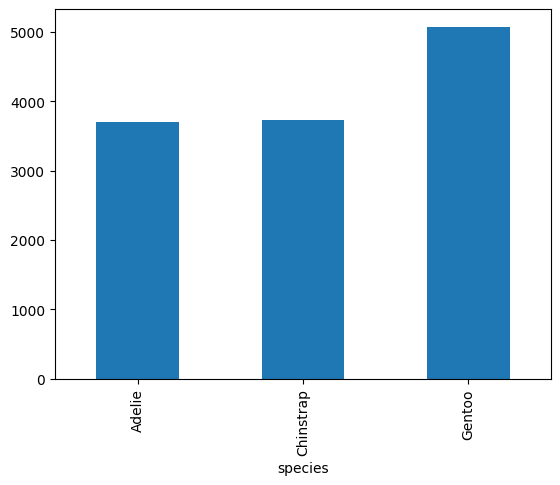

In [138]:
# First calculate the average body mass for every species.
average_mass = df.groupby("species")["body_mass_g"].mean()

# plot() creates a visualization of the result.
# kind="bar" asks pandas to create a bar chart.
average_mass.plot(kind="bar")

<Axes: title={'center': 'Average Body Mass by Species'}, xlabel='species'>

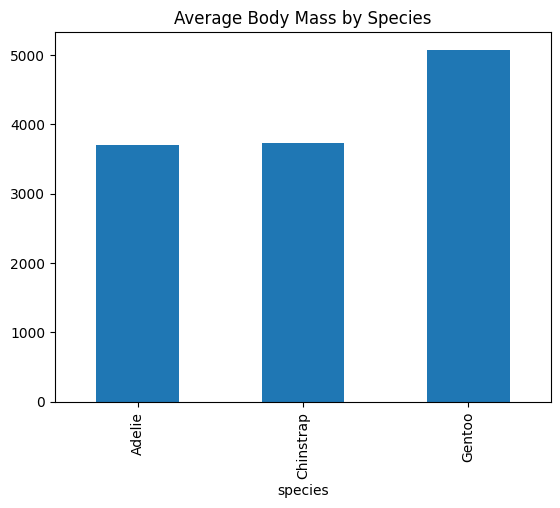

In [139]:
average_mass.plot(
    kind="bar",
    title="Average Body Mass by Species"
)

#### 2. Histogram: understand a distribution

<Axes: title={'center': 'Distribution of Penguin Body Mass'}, ylabel='Frequency'>

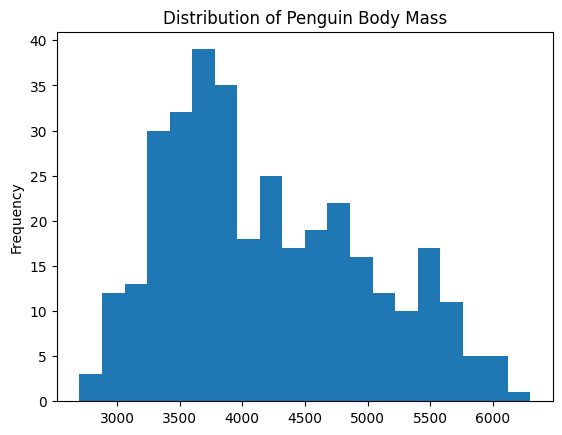

In [140]:
# A histogram shows how numerical values are distributed.
# The values are divided into intervals ("bins").
df["body_mass_g"].plot(
    kind="hist",
    bins=20,
    title="Distribution of Penguin Body Mass"
)

playing with the bins parameter

<Axes: ylabel='Frequency'>

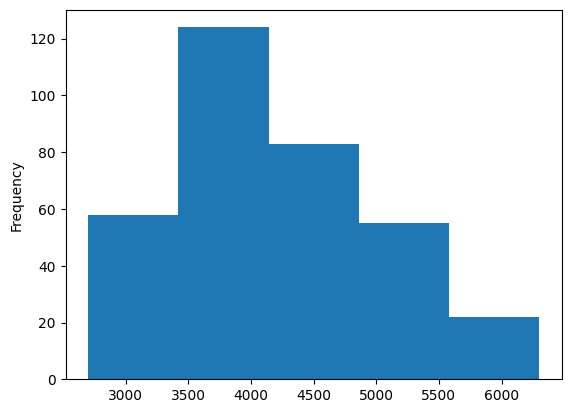

In [141]:
df["body_mass_g"].plot(kind="hist", bins=5)

<Axes: ylabel='Frequency'>

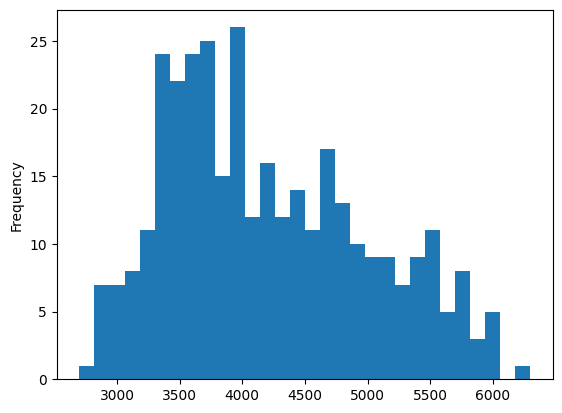

In [142]:
df["body_mass_g"].plot(kind="hist", bins=30)

#### 3. Scatter plot: relationships between variables

<Axes: title={'center': 'Flipper Length vs Body Mass'}, xlabel='flipper_length_mm', ylabel='body_mass_g'>

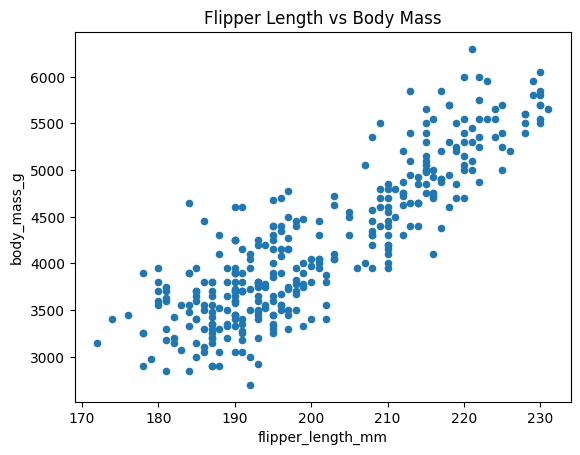

In [143]:
# A scatter plot helps us examine the relationship
# between two numerical variables.
df.plot(
    kind="scatter",
    x="flipper_length_mm",
    y="body_mass_g",
    title="Flipper Length vs Body Mass"
)

#### 4. Box plot: compare distributions

<Axes: title={'center': 'body_mass_g'}, xlabel='species'>

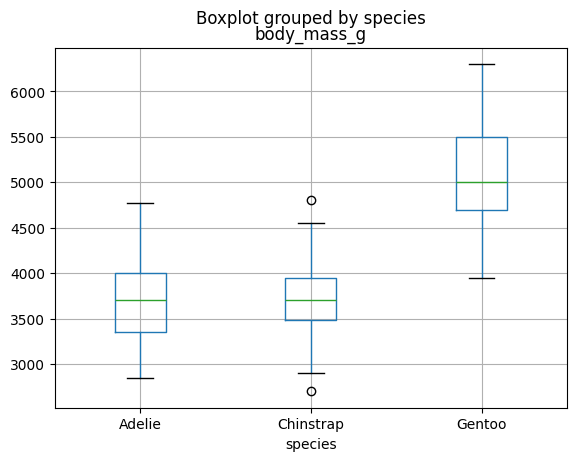

In [144]:
# A box plot summarizes the distribution of a numerical variable
# and makes it easy to compare groups.
df.boxplot(
    column="body_mass_g",
    by="species"
)

#### Matplotlib

Pandas provides convenient functions for data visualization. However, behind the scene it relies on matplotlib

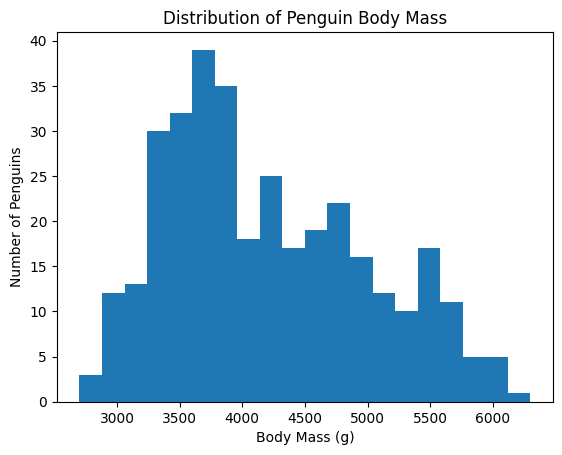

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the histogram, dropping NaN values for the input
n, bins, patches = plt.hist(df["body_mass_g"].dropna(), bins=20)

# Get a pastel color palette from seaborn, matching the number of bins
colors = sns.color_palette("pastel", len(patches))

# Apply the colors to each bar of the histogram
for i, patch in enumerate(patches):
    patch.set_facecolor(colors[i])

# Add information that makes the visualization easier to understand.
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (g)")
plt.ylabel("Number of Penguins")

plt.show()

Let's try to make that graph more colorful. ask gemini to explain you the code of the cell. Then use the following prompt:

```text
In this cell how can I make the histogram more colorful with each bar in a different color but using a pastel color palette?
```

The result should be something similar to this:

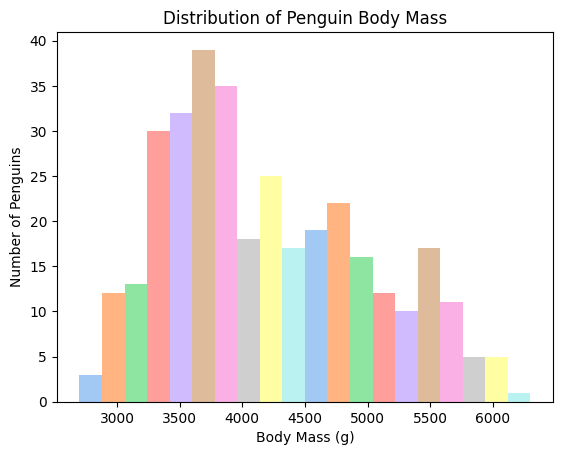

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the histogram, dropping NaN values for the input
n, bins, patches = plt.hist(df["body_mass_g"].dropna(), bins=20)

# Get a pastel color palette from seaborn, matching the number of bins
colors = sns.color_palette("pastel", len(patches))

# Apply the colors to each bar of the histogram
for i, patch in enumerate(patches):
    patch.set_facecolor(colors[i])

# Add information that makes the visualization easier to understand.
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (g)")
plt.ylabel("Number of Penguins")

plt.show()

How to choose the right chart?

| Question                                    | Visualization |
| ------------------------------------------- | ------------- |
| How do categories compare?                  | Bar chart     |
| How is one numerical variable distributed?  | Histogram     |
| Are two numerical variables related?        | Scatter plot  |
| How do distributions differ between groups? | Box plot      |


---
#### **Exercise: Explore the Penguins Dataset**

Using the df DataFrame from the previous examples, complete the following tasks.

1. Display the first 8 rows of the dataset.
2. Find all penguins with a body mass greater than 5000 grams.
3. Count the number of missing values in each column.
4. Create a new column called body_mass_kg containing the body mass in kilograms.
5. Calculate the average body mass in kilograms for each species.
6. Create a bar chart showing the average body mass for each species.

Question: Which species has the highest average body mass?

In [ ]:
# first import the pandas library
import pandas as pd

# define where the dataset is located
dataset_path = "/content/drive/MyDrive/My_Courses/PP4AI/Datasets/penguins.csv"

# Read the dataset into a panda's dataframe
df = pd.read_csv(dataset_path)

In [ ]:
# 1. Display the first 8 rows



In [ ]:
# 2. Find all penguins with a body mass greater than 5000 grams



In [ ]:
# 3. Count the number of missing values in each column



In [ ]:
# 4. Create a new column called body_mass_kg containing the body mass in kilograms.



In [ ]:
# 5. Calculate the average body mass in kilograms for each species.



In [ ]:
# 6. Create a bar chart showing the average body mass for each species.



#### Bonus Task:

Find only Gentoo penguins weighing more than 5 kg and sort them from heaviest to lightest.

In [ ]:
# write your code here



---
Read after finishing or if you are stuck

---

In [ ]:
# 1. Display the first 8 rows
df.head(8)

In [ ]:
# 2. Keep only penguins heavier than 5000 grams
heavy_penguins = df[df["body_mass_g"] > 5000]

heavy_penguins

In [ ]:
# 3. Count missing values in each column
df.isna().sum()

In [ ]:
# 4. Convert body mass from grams to kilograms
df["body_mass_kg"] = df["body_mass_g"] / 1000

df[["species", "body_mass_g", "body_mass_kg"]].head()

In [ ]:
# 5. Calculate the average body mass for each species
average_mass = df.groupby("species")["body_mass_kg"].mean()

average_mass

In [ ]:
# 6. Visualize the result
average_mass.plot(
    kind="bar",
    title="Average Body Mass by Species"
)

In [ ]:
# Bonus
df[
    (df["species"] == "Gentoo")
    & (df["body_mass_kg"] > 5)
].sort_values("body_mass_kg", ascending=False)

---
#### Extra Practice

---

Use everything that we have learn from pandas and analyze the tips dataset by yourself. You choose what to do!

Columns meaning:

| Column       | Meaning                            |
| ------------ | ---------------------------------- |
| `total_bill` | Total value of the restaurant bill |
| `tip`        | Tip left by the customer           |
| `sex`        | Sex of the person paying the bill  |
| `smoker`     | Whether the party included smokers |
| `day`        | Day of the week                    |
| `time`       | Lunch or dinner                    |
| `size`       | Number of people in the party      |



In [ ]:
import pandas as pd

# Load a new dataset containing information about
# restaurant bills, tips, customers, and dining occasions.
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/tips.csv"

tips = pd.read_csv(url)

# Start exploring!
tips.head()

In [ ]:
# Write your code here



**Some ideas if you don't know where to start:**

What does the dataset look like? Are there missing values? What are typical bills and tips? Do tips appear related to the bill amount? Are there differences between days or between lunch and dinner? Can you create a new variable that might be interesting? Can you visualize something you discover?